# Introduction à la bibliothèque Seaborn

Seaborn est une bibliothèque permettant de créer des graphiques statistiques en Python. Elle s'appuie sur matplotlib et s'intègre étroitement aux structures de données pandas.

Seaborn vous aide à explorer et à comprendre vos données. Ses fonctions de traçage fonctionnent sur des trames de données et des tableaux contenant des ensembles de données entiers et effectuent en interne le mappage sémantique et l'agrégation statistique nécessaires pour produire des tracés informatifs. Son API déclarative orientée vers les ensembles de données vous permet de vous concentrer sur la signification des différents éléments de vos tracés, plutôt que sur les détails de leur tracé.

Voici un exemple de ce que Seaborn peut faire :

In [3]:
# Importation de la bibliothèque
import seaborn as sns

En coulisses, seaborn utilise matplotlib pour dessiner ses tracés. Pour un travail interactif, il est recommandé d'utiliser une interface Jupyter/IPython en mode matplotlib , sinon vous devrez l'appeler matplotlib.pyplot.show()lorsque vous voudrez voir le tracé.

## Création d'un graphique rapidement

In [5]:
# Thème par défaut
sns.set_theme()

Cela utilise le système rcParam de matplotlib et affectera l'apparence de tous les tracés de matplotlib, même si vous ne les créez pas avec seaborn. Au-delà du thème par défaut, il existe plusieurs autres options , et vous pouvez contrôler indépendamment le style et la mise à l'échelle du tracé pour traduire rapidement votre travail entre les contextes de présentation (par exemple, en créant une version de votre figure qui aura des polices lisibles lorsqu'elle sera projetée pendant une conférence). Si vous aimez les valeurs par défaut de matplotlib ou préférez un thème différent, vous pouvez ignorer cette étape et continuer à utiliser les fonctions de traçage de seaborn.

In [7]:
# Chargement d'un dataset exemple
tips = sns.load_dataset("tips")

La plupart des codes de la documentation utiliseront la load_dataset()fonction pour accéder rapidement à un exemple d'ensemble de données. Ces ensembles de données n'ont rien de spécial : ce ne sont que des dataframes pandas, et nous aurions pu les charger pandas.read_csv()ou les créer à la main. La plupart des exemples de la documentation spécifieront les données à l'aide de dataframes pandas, mais seaborn est très flexible quant aux structures de données qu'il accepte.

In [9]:
tips

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4
...,...,...,...,...,...,...,...
239,29.03,5.92,Male,No,Sat,Dinner,3
240,27.18,2.00,Female,Yes,Sat,Dinner,2
241,22.67,2.00,Male,Yes,Sat,Dinner,2
242,17.82,1.75,Male,No,Sat,Dinner,2


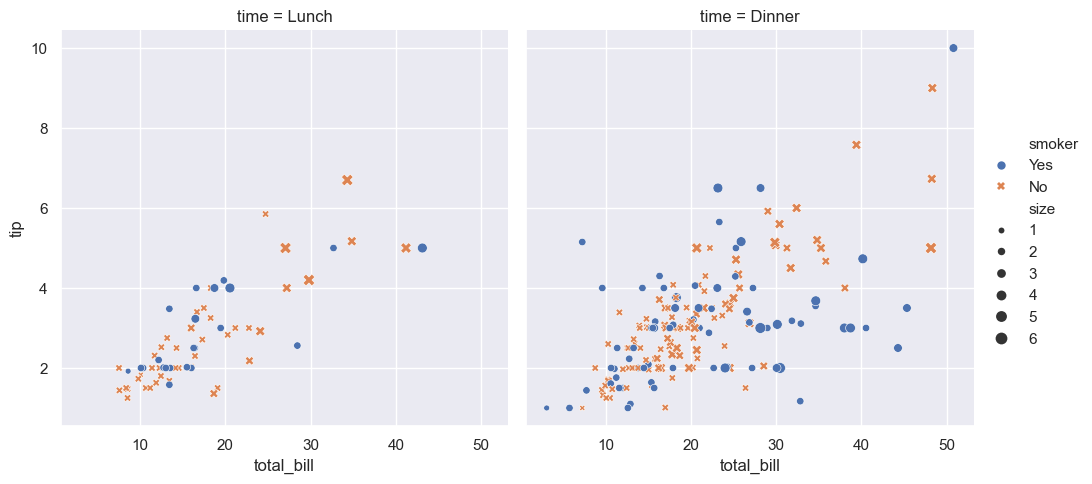

In [11]:
# création d'une visualisation
# Create a visualization
sns.relplot(
    data=tips,
    x="total_bill", y="tip", col="time",
    hue="smoker", style="smoker", size="size",
)

Ce graphique montre la relation entre cinq variables dans l'ensemble de données tips à l'aide d'un seul appel à la fonction seaborn relplot(). Notez que nous avons fourni uniquement les noms des variables et leurs rôles dans le graphique. Contrairement à l'utilisation directe de matplotlib, il n'était pas nécessaire de spécifier les attributs des éléments du graphique en termes de valeurs de couleur ou de codes de marqueur. En coulisses, seaborn a géré la traduction des valeurs du dataframe en arguments que matplotlib comprend. Cette approche déclarative vous permet de rester concentré sur les questions auxquelles vous souhaitez répondre, plutôt que sur les détails de contrôle de matplotlib.

## Une API de haut niveau pour les graphiques statistiques

Il n'existe pas de méthode universellement optimale pour visualiser les données. Différentes questions sont mieux répondues par différents graphiques. Seaborn facilite le basculement entre différentes représentations visuelles en utilisant une API cohérente orientée vers les ensembles de données.

La fonction relplot()est nommée ainsi car elle est conçue pour visualiser de nombreuses relations statistiques différentes . Bien que les diagrammes de dispersion soient souvent efficaces, les relations dans lesquelles une variable représente une mesure de temps sont mieux représentées par une ligne. La relplot()fonction dispose d'un paramètre pratique ki ndqui vous permet de passer facilement à cette représentation alternative :

In [16]:
dots = sns.load_dataset("dots")
dots

,align,choice,time,coherence,firing_rate
0,dots,T1,-80,0.0,33.189967
1,dots,T1,-80,3.2,31.691726
2,dots,T1,-80,6.4,34.279840
3,dots,T1,-80,12.8,32.631874
4,dots,T1,-80,25.6,35.060487
...,...,...,...,...,...
843,sacc,T2,300,3.2,33.281734
844,sacc,T2,300,6.4,27.583979
845,sacc,T2,300,12.8,28.511530
846,sacc,T2,300,25.6,27.009804


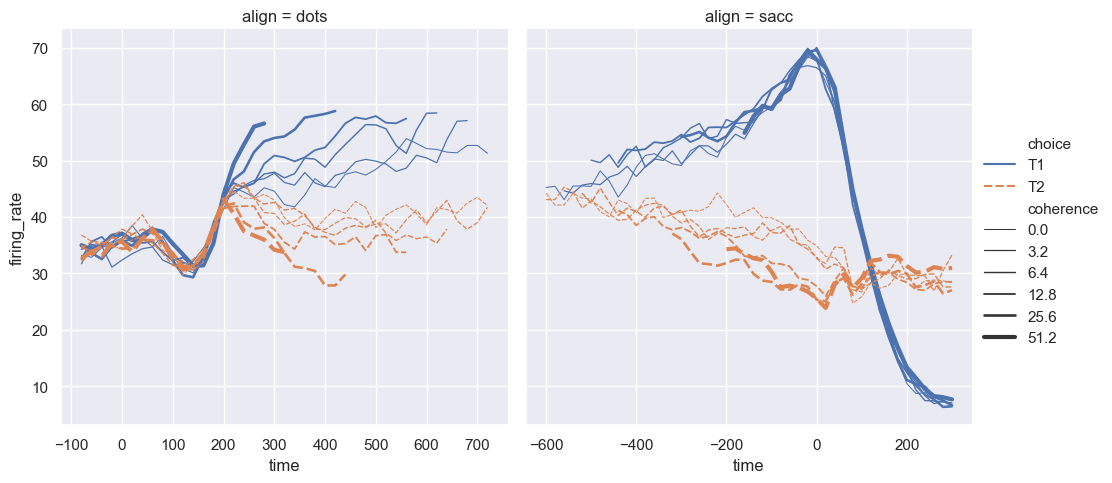

In [22]:
sns.relplot(
    data=dots, kind="line",
    x="time", y="firing_rate", col="align",
    hue="choice", size="coherence", style="choice",
    facet_kws=dict(sharex=False),
)

In [ ]:
dots

## Estimation statistique

Souvent, nous nous intéressons à la valeur moyenne d'une variable en fonction d'autres variables. De nombreuses fonctions Seaborn effectueront automatiquement l'estimation statistique nécessaire pour répondre à ces questions :

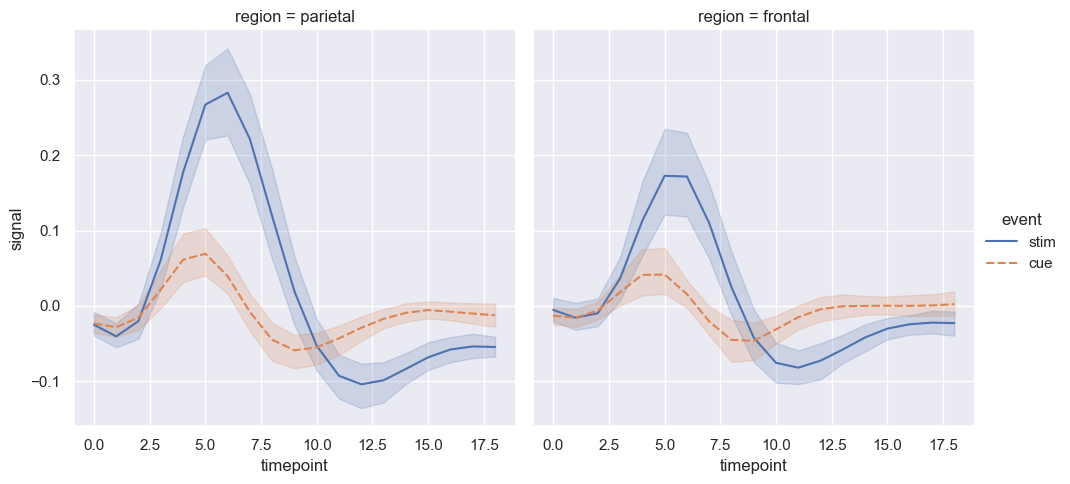

In [24]:
fmri = sns.load_dataset("fmri")
sns.relplot(
    data=fmri, kind="line",
    x="timepoint", y="signal", col="region",
    hue="event", style="event",
)

Lorsque des valeurs statistiques sont estimées, Seaborn utilisera le bootstrapping pour calculer les intervalles de confiance et dessiner des barres d’erreur représentant l’incertitude de l’estimation.

L'estimation statistique dans Seaborn va au-delà des statistiques descriptives. Par exemple, il est possible d'améliorer un nuage de points en incluant un modèle de régression linéaire (et son incertitude) en utilisant lmplot():

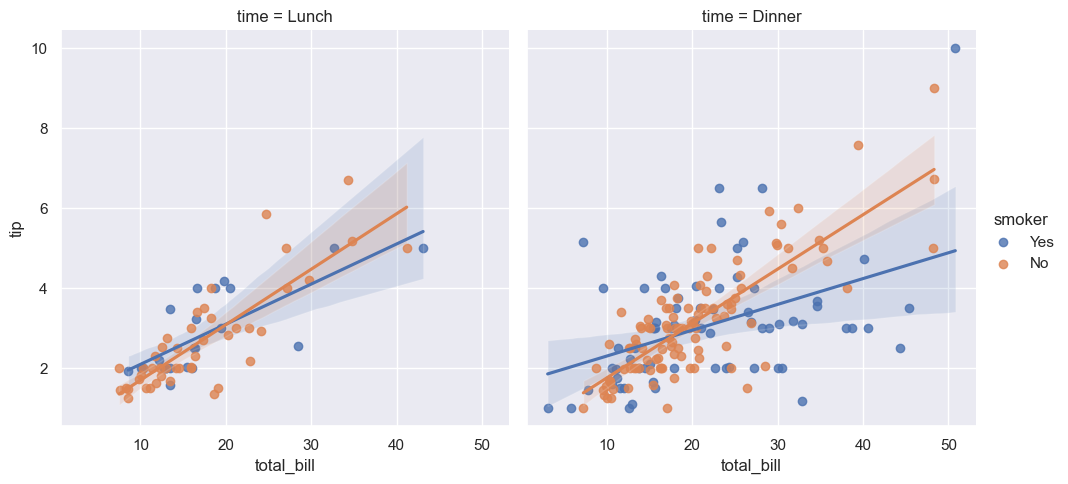

In [26]:
sns.lmplot(data=tips, x="total_bill", y="tip", col="time", hue="smoker")

## Représentations distributionnelles

Les analyses statistiques nécessitent des connaissances sur la distribution des variables dans votre ensemble de données. La fonction seaborn displot() prend en charge plusieurs approches de visualisation des distributions. Il s'agit notamment de techniques classiques comme les histogrammes et d'approches gourmandes en calcul comme l'estimation de la densité du noyau :

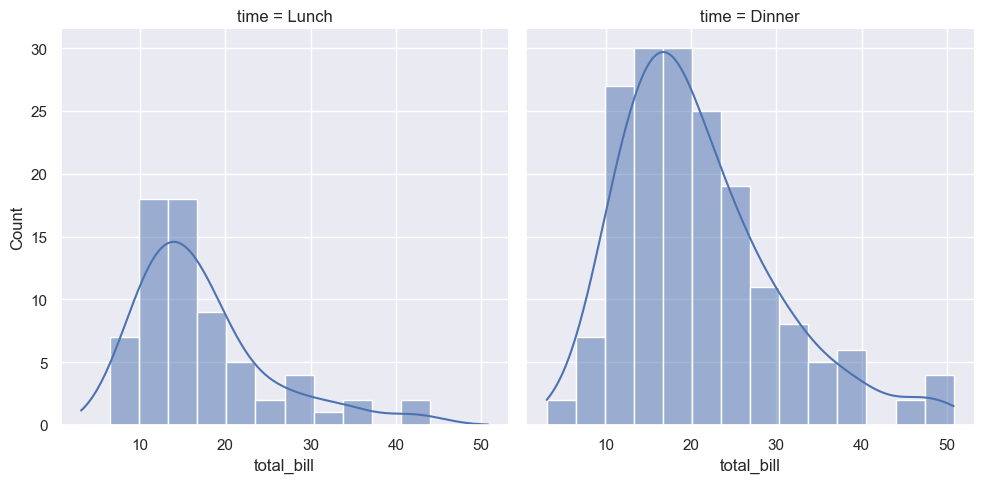

In [32]:
sns.displot(data=tips, x="total_bill", col="time", kde=True)

Seaborn essaie également de promouvoir des techniques puissantes mais moins familières, telles que le calcul et le tracé de la fonction de distribution cumulative empirique des données :

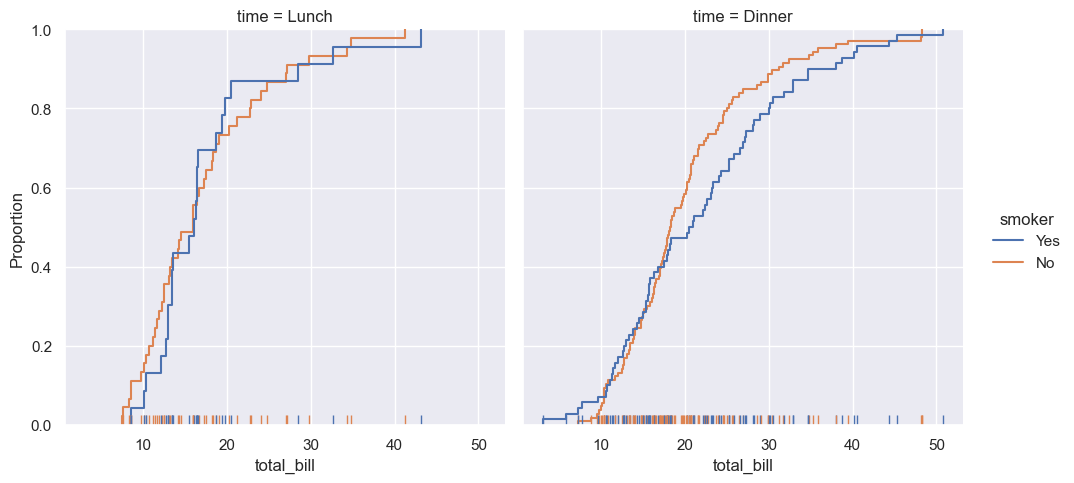

In [34]:
sns.displot(data=tips, kind="ecdf", x="total_bill", col="time", hue="smoker", rug=True)

## Graphiques pour données catégorielles

Plusieurs types de tracés spécialisés dans Seaborn sont orientés vers la visualisation de données catégorielles. Ils sont accessibles via catplot(). Ces tracés offrent différents niveaux de granularité. Au niveau le plus fin, vous souhaiterez peut-être voir chaque observation en dessinant un tracé « en essaim » : un nuage de points qui ajuste les positions des points le long de l'axe catégoriel afin qu'ils ne se chevauchent pas :

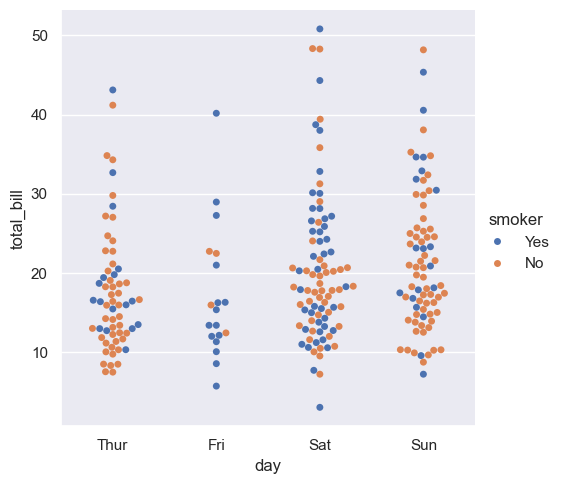

In [36]:
sns.catplot(data=tips, kind="swarm", x="day", y="total_bill", hue="smoker")

Alternativement, vous pouvez utiliser l'estimation de la densité du noyau pour représenter la distribution sous-jacente à partir de laquelle les points sont échantillonnés :

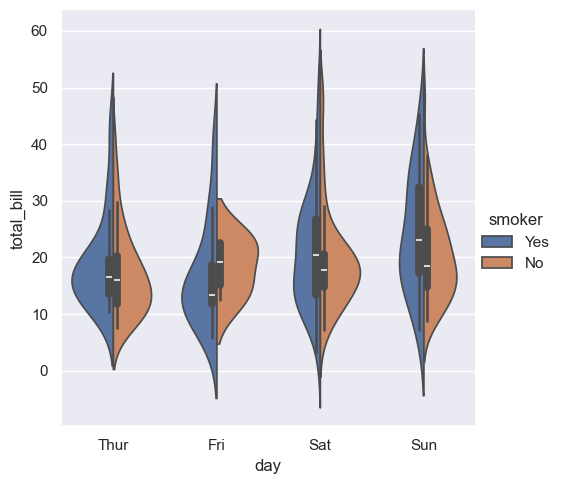

In [38]:
sns.catplot(data=tips, kind="violin", x="day", y="total_bill", hue="smoker", split=True)

Ou vous pouvez afficher uniquement la valeur moyenne et son intervalle de confiance dans chaque catégorie imbriquée :



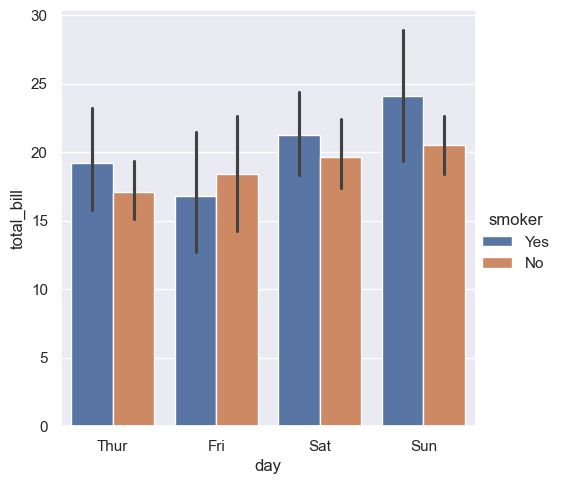

In [40]:
sns.catplot(data=tips, kind="bar", x="day", y="total_bill", hue="smoker")

## Vues multivariées sur des ensembles de données complexes 

Certaines fonctions Seaborn combinent plusieurs types de tracés pour fournir rapidement des résumés informatifs d'un ensemble de données. L'une d'elles, jointplot(), se concentre sur une seule relation. Elle trace la distribution conjointe entre deux variables ainsi que la distribution marginale de chaque variable :

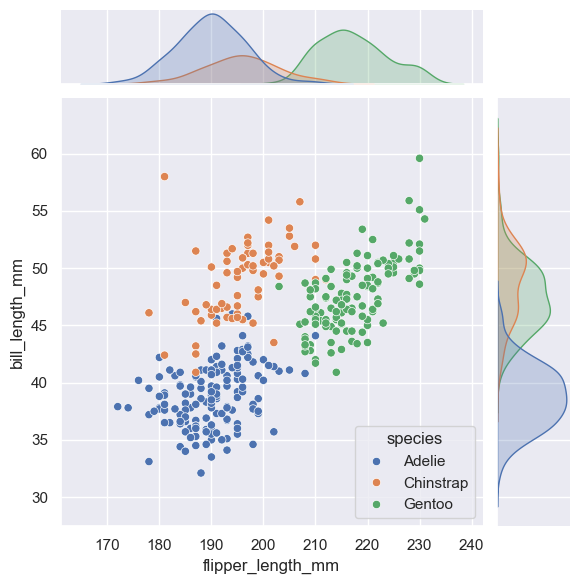

In [42]:
penguins = sns.load_dataset("penguins")
sns.jointplot(data=penguins, x="flipper_length_mm", y="bill_length_mm", hue="species")

L'autre, pairplot(), adopte une vision plus large : elle montre les distributions conjointes et marginales pour toutes les relations par paires et pour chaque variable, respectivement :

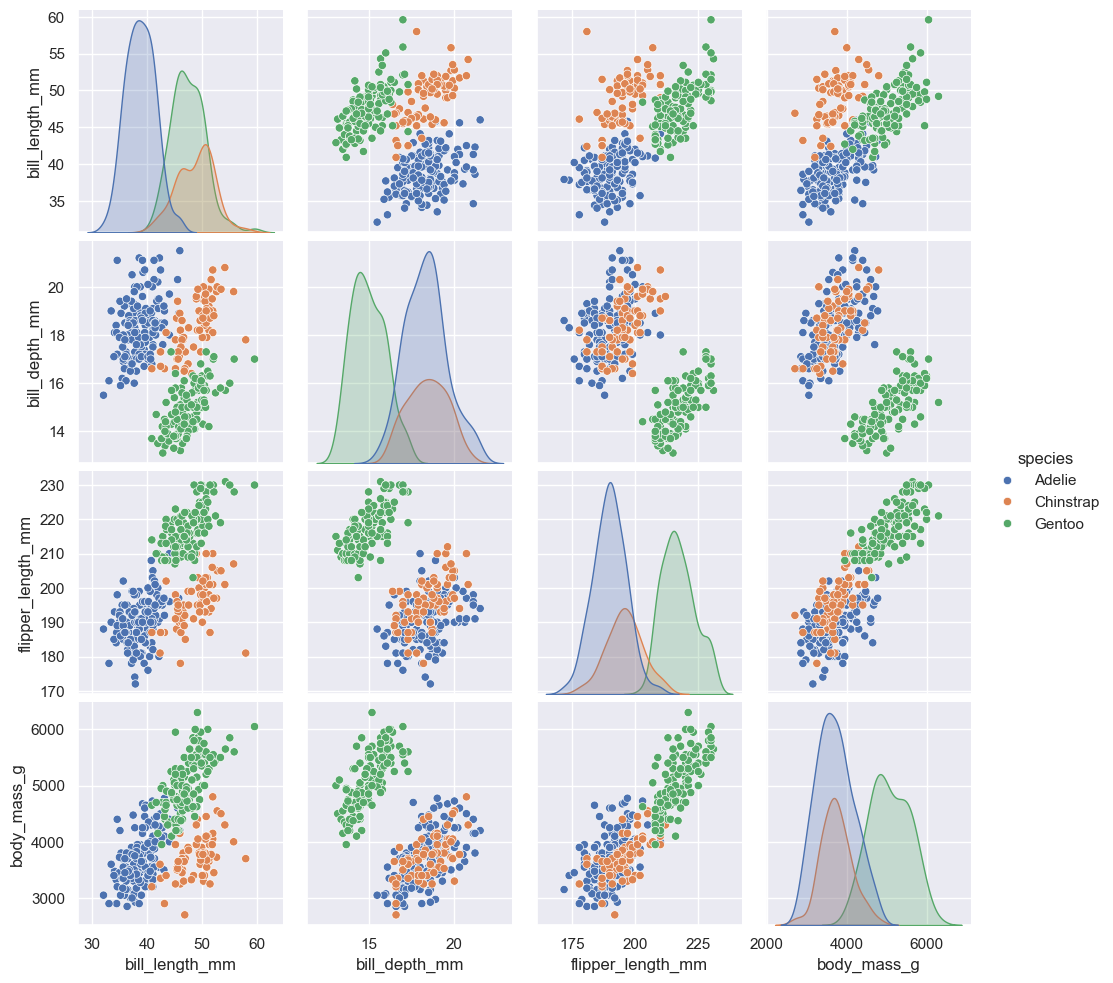

In [44]:
sns.pairplot(data=penguins, hue="species")

## Outils de niveau inférieur pour la construction de figures 

Ces outils fonctionnent en combinant des fonctions de traçage au niveau des axes avec des objets qui gèrent la mise en page de la figure, en reliant la structure d'un ensemble de données à une grille d'axes . Les deux éléments font partie de l'API publique et vous pouvez les utiliser directement pour créer des figures complexes avec seulement quelques lignes de code supplémentaires :

In [46]:
penguins

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
...,...,...,...,...,...,...,...
339,Gentoo,Biscoe,NaN,NaN,NaN,NaN,NaN
340,Gentoo,Biscoe,46.8,14.3,215.0,4850.0,Female
341,Gentoo,Biscoe,50.4,15.7,222.0,5750.0,Male
342,Gentoo,Biscoe,45.2,14.8,212.0,5200.0,Female


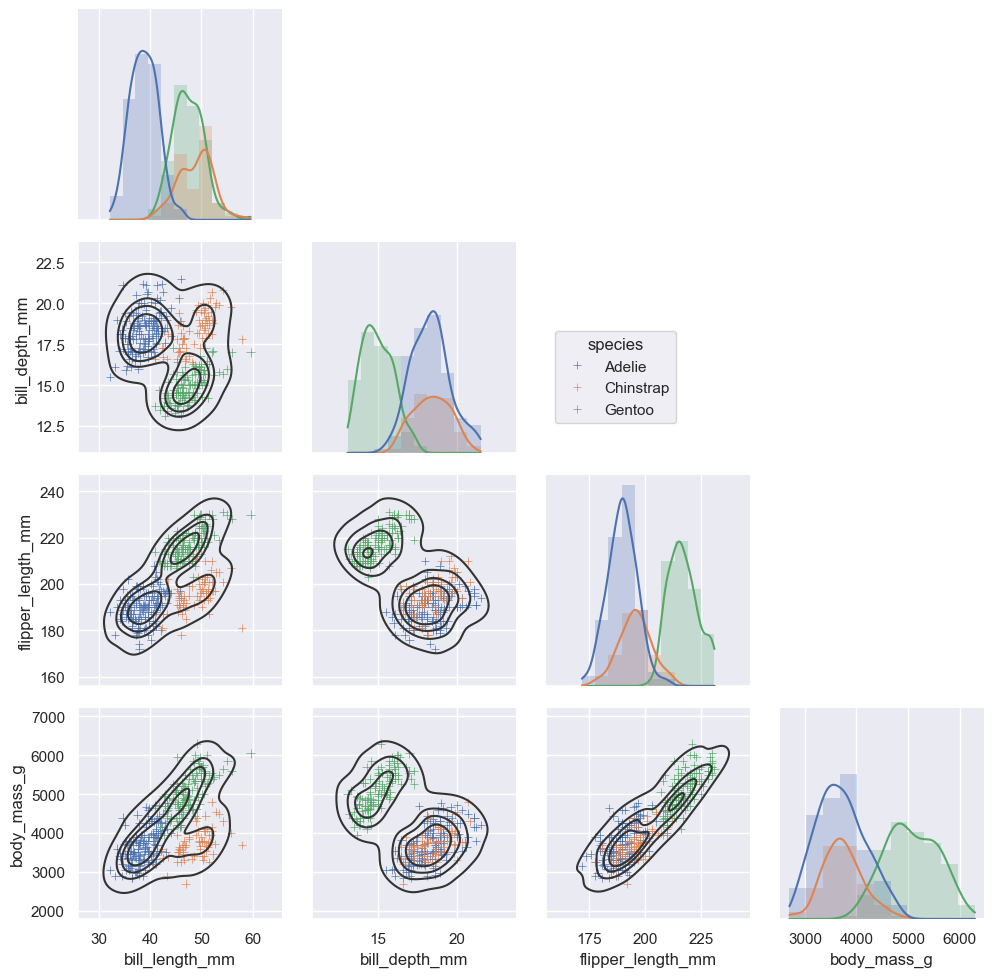

In [48]:
g = sns.PairGrid(penguins, hue="species", corner=True)
g.map_lower(sns.kdeplot, hue=None, levels=5, color=".2")
g.map_lower(sns.scatterplot, marker="+")
g.map_diag(sns.histplot, element="step", linewidth=0, kde=True)
g.add_legend(frameon=True)
g.legend.set_bbox_to_anchor((.61, .6))

## Valeurs par défaut avisées et personnalisation flexible 

Seaborn crée des graphiques complets avec un seul appel de fonction : lorsque cela est possible, ses fonctions ajouteront automatiquement des étiquettes d'axe informatives et des légendes qui expliquent les mappages sémantiques dans le tracé.

Dans de nombreux cas, seaborn choisira également des valeurs par défaut pour ses paramètres en fonction des caractéristiques des données. Par exemple, les mappages de couleurs que nous avons vus jusqu'à présent utilisaient des teintes distinctes (bleu, orange et parfois vert) pour représenter différents niveaux des variables catégorielles attribuées à hue. Lors du mappage d'une variable numérique, certaines fonctions passeront à un dégradé continu :

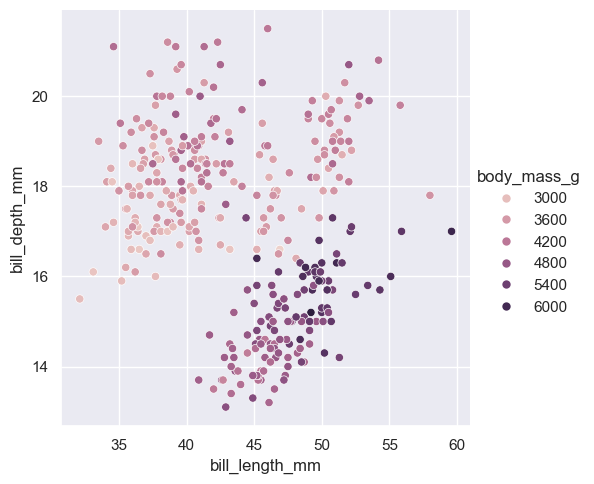

In [50]:
sns.relplot(
    data=penguins,
    x="bill_length_mm", y="bill_depth_mm", hue="body_mass_g"
)

Lorsque vous êtes prêt à partager ou à publier votre travail, vous souhaiterez probablement peaufiner la figure au-delà de ce que les valeurs par défaut permettent d'accomplir. Seaborn permet plusieurs niveaux de personnalisation. Il définit plusieurs thèmes intégrés qui s'appliquent à toutes les figures, ses fonctions ont des paramètres standardisés qui peuvent modifier les mappages sémantiques pour chaque tracé, et des arguments de mots-clés supplémentaires sont transmis aux artistes matplotlib sous-jacents, permettant encore plus de contrôle. Une fois que vous avez créé un tracé, ses propriétés peuvent être modifiées à la fois via l'API Seaborn et en descendant vers la couche matplotlib pour un réglage précis :


Text(0.5, 1.0, 'Mon graphique')

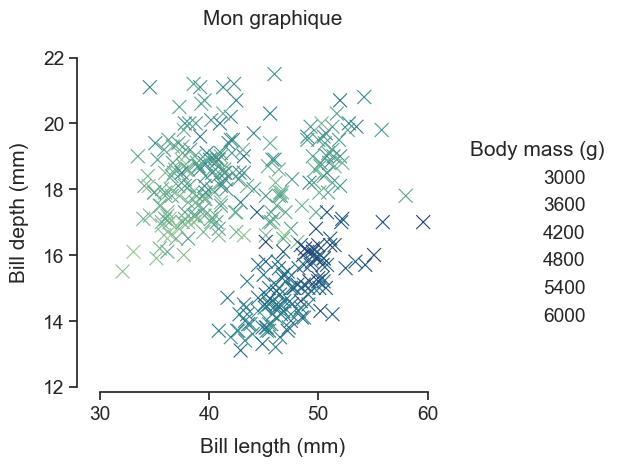

In [52]:
import matplotlib.pyplot as plt
sns.set_theme(style="ticks", font_scale=1.25)
g = sns.relplot(
    data=penguins,
    x="bill_length_mm", y="bill_depth_mm", hue="body_mass_g",
    palette="crest", marker="x", s=100,
)
g.set_axis_labels("Bill length (mm)", "Bill depth (mm)", labelpad=10)
g.legend.set_title("Body mass (g)")
g.figure.set_size_inches(6.5, 4.5)
g.ax.margins(.15)
g.despine(trim=True)
plt.title("Mon graphique")

## Relation avec matplotlib 

L'intégration de Seaborn avec matplotlib vous permet de l'utiliser dans les nombreux environnements pris en charge par matplotlib, notamment l'analyse exploratoire dans les notebooks, l'interaction en temps réel dans les applications GUI et la sortie d'archivage dans un certain nombre de formats raster et vectoriels.

Bien que vous puissiez être productif en utilisant uniquement les fonctions de Seaborn, la personnalisation complète de vos graphiques nécessitera une certaine connaissance des concepts et de l'API de Matplotlib. Un aspect de la courbe d'apprentissage pour les nouveaux utilisateurs de Seaborn sera de savoir quand il est nécessaire de passer à la couche Matplotlib pour réaliser une personnalisation particulière. D'un autre côté, les utilisateurs venant de Matplotlib constateront qu'une grande partie de leurs connaissances sont transférées.

Matplotlib dispose d'une API complète et puissante ; presque tous les attributs de la figure peuvent être modifiés à votre guise. Une combinaison de l'interface de haut niveau de Seaborn et de la personnalisation approfondie de Matplotlib vous permettra à la fois d'explorer rapidement vos données et de créer des graphiques qui peuvent être adaptés pour obtenir un produit final de qualité publi.le .